<a href="https://colab.research.google.com/github/7235SYXD/Real-Estate/blob/main/DSP_on_Real_Estate_(Notebook_5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — INSTALL LIBRARIES                                      ║
# ╚══════════════════════════════════════════════════════════════════╝

import subprocess, sys
for lib in ["kagglehub","catboost","shap","optuna",
            "vaderSentiment","yake","textstat"]:
    subprocess.run([sys.executable,"-m","pip","install",lib,"-q"])
print("All libraries installed.")

All libraries installed.


In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — GOOGLE DRIVE                                           ║
# ╚══════════════════════════════════════════════════════════════════╝

import os, shutil
from google.colab import drive, files

drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive/RealEstate_TXNY"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save directory: {SAVE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Save directory: /content/drive/MyDrive/RealEstate_TXNY


In [3]:
# ╔════════════════════════════════════════════════════╗
# ║  CELL 3 — IMPORT ALL LIBRARIES                     ║
# ╚════════════════════════════════════════════════════╝

import os
import re
import warnings
from pathlib import Path
import gc # Import the garbage collection module

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from tensorflow.keras import layers as KL

# Sklearn
from sklearn.model_selection import train_test_split, KFold, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, f1_score, classification_report,
    accuracy_score,
)

# Gradient boosting
!pip install catboost
from catboost import CatBoostRegressor, CatBoostClassifier
import xgboost as xgb

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Hyperparameter tuning
!pip install optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Interpretability
import shap

# NLP
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
!pip install yake
import yake
!pip install textstat
import textstat

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.4f}".format)

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 60)
print("All libraries imported successfully.")
print(f"  pandas     : {pd.__version__}")
print(f"  numpy      : {np.__version__}")
print(f"  tensorflow : {tf.__version__}")
print(f"  sklearn    : OK")
print("=" * 60)

All libraries imported successfully.
  pandas     : 2.2.2
  numpy      : 2.0.2
  tensorflow : 2.20.0
  sklearn    : OK


In [4]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "dill", "-q"])
import dill, json
import os # Import os module for path checks

CKPT_DIR  = f"{SAVE_DIR}/checkpoints"
CKPT_NAME = "checkpoint_4_to_5"
PKL_FILE_PATH = f"{CKPT_DIR}/{CKPT_NAME}.pkl"
KERAS_JSON_PATH = f"{CKPT_DIR}/{CKPT_NAME}_keras.json"

_state = {} # Initialize _state to an empty dictionary in case of error
_keras_paths = {} # Initialize _keras_paths to an empty dictionary in case of error

print("=" * 65)
print(f"Attempting to restore checkpoint from: {PKL_FILE_PATH}")
print("=" * 65)

if not os.path.exists(PKL_FILE_PATH):
    print(f"ERROR: Checkpoint file '{PKL_FILE_PATH}' not found.")
    print("Please ensure 'Notebook 4' has been run and its state saved successfully to Google Drive.")
    print("Skipping state restoration.")
else:
    try:
        with open(PKL_FILE_PATH, "rb") as f:
            _state = dill.load(f)
        globals().update(_state)
        print(f"CHECKPOINT RESTORED <- {PKL_FILE_PATH}")

        if not os.path.exists(KERAS_JSON_PATH):
            print(f"WARNING: Keras models checkpoint file '{KERAS_JSON_PATH}' not found. Keras models will not be restored.")
        else:
            try:
                with open(KERAS_JSON_PATH) as f:
                    _keras_paths = json.load(f)
                for _name, _path in _keras_paths.items():
                    # Assume 'keras' is available globally from earlier imports (e.g., cell bkVVmwXvBonL)
                    globals()[_name] = keras.models.load_model(_path)
            except Exception as e:
                print(f"WARNING: Failed to load Keras models from '{KERAS_JSON_PATH}': {e}")
                _keras_paths = {} # Clear if loading failed

    except EOFError:
        print(f"ERROR: EOFError encountered while loading '{PKL_FILE_PATH}'.")
        print("This often means the checkpoint file is empty or corrupted.")
        print("Please verify 'Notebook 4' saved its state correctly.")
        _state = {} # Clear state if loading failed
    except Exception as e:
        print(f"ERROR: An unexpected error occurred while loading '{PKL_FILE_PATH}': {e}")
        _state = {} # Clear state if loading failed

# Summary output, whether restoration was successful or not
print("=" * 65)
print(f"  Variables restored    : {len(_state)}")
print(f"  Keras models restored : {list(_keras_paths.keys()) or 'none'}")
if "df_combined" in globals():
    print(f"  df_combined shape      : {df_combined.shape}")
print(f"\nNotebook 3 state loaded successfully." if len(_state) > 0 else "\nNotebook 3 state NOT fully loaded.")
print("Continuing from Cell 27 below, unchanged.")

Attempting to restore checkpoint from: /content/drive/MyDrive/RealEstate_TXNY/checkpoints/checkpoint_4_to_5.pkl
CHECKPOINT RESTORED <- /content/drive/MyDrive/RealEstate_TXNY/checkpoints/checkpoint_4_to_5.pkl
  Variables restored    : 412
  Keras models restored : ['mlp_base_model', 'mlp_tuned', 'mlp_f']
  df_combined shape      : (149999, 51)

Notebook 3 state loaded successfully.
Continuing from Cell 27 below, unchanged.


In [5]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 28 — RIDGE STACKING META-LEARNER                           ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Train a Ridge meta-learner on OOF predictions.

Why Ridge for the meta-learner:
  • Ridge = L2 regularised linear regression. It blends the base model
    predictions with coefficients that sum approximately to 1.
  • A coefficient close to 0 means that model adds little to the ensemble.
  • A negative coefficient means the model is hurting the ensemble —
    this flags an unstable model (like MLP if it collapsed).
  • Ridge prevents the meta-learner from overfitting to the noise in
    each base model's OOF predictions.

Meta-feature matrix:
  Columns: [oof_rf, oof_cat, (oof_mlp), oof_hgb, oof_en]
  Rows:    one per training sample (n_train rows)
  Target:  y_reg_train (actual log_price)

Test predictions: each base model predicts on the full test set,
  producing test-level meta-features for the Ridge meta-learner.
"""

print("=" * 65)
print("CELL 27 — RIDGE STACKING META-LEARNER")
print("=" * 65)

from sklearn.linear_model import Ridge as RidgeMeta

# Build OOF meta-feature matrix
oof_cols = [oof_rf, oof_cat, oof_hgb]
oof_names = ["RF", "CatBoost", "HGB"]
if INCLUDE_MLP_IN_STACK:
    oof_cols.insert(2, oof_mlp)
    oof_names.insert(2, "MLP")

meta_train = np.column_stack(oof_cols)
print(f"Meta-feature matrix (train): {meta_train.shape}  "
      f"columns={oof_names}")

# Train Ridge meta-learner
ridge_meta = RidgeMeta(alpha=1.0)
ridge_meta.fit(meta_train, yr_train_vals)
print(f"\nRidge meta-learner coefficients:")
for name, coef in zip(oof_names, ridge_meta.coef_):
    bar = "█" * max(0, int(abs(coef) * 20))
    flag = " negative stack" if coef < 0 else ""
    print(f"  {name:14s}: {coef:+.4f}  {bar}{flag}")
print(f"  Intercept     : {ridge_meta.intercept_:.4f}")

# ── Test set predictions ───────────────────────────────────────────
print("\nGenerating test-set predictions from tuned models ...")
p_rf_test  = rf_tuned.predict(Xts_rf)
p_cat_test = cb_tuned.predict(Xts_rf)
p_hgb_test = hgb_tuned.predict(Xts_raw)
# p_en_test  = en_tuned.predict(Xts_sc) # Removed as oof_en was not defined
p_mlp_test = denorm_y(mlp_tuned.predict(Xts_sc, verbose=0).flatten())

test_cols = [p_rf_test, p_cat_test, p_hgb_test]
test_names = ["RF", "CatBoost", "HGB"]
if INCLUDE_MLP_IN_STACK:
    test_cols.insert(2, p_mlp_test)
    test_names.insert(2, "MLP")

meta_test   = np.column_stack(test_cols)
p_stk_test  = ridge_meta.predict(meta_test)

# ── Final test-set evaluation ──────────────────────────────────────
print(f"\n{'='*65}")
print("FINAL TEST SET RESULTS — ALL TUNED MODELS + STACK")
print(f"{'='*65}")
final_results = []
for name, preds, Xts_arr in [
    ("RF (tuned)",           p_rf_test,  None),
    ("CatBoost (tuned)",     p_cat_test, None),
    ("MLP (residual,tuned)", p_mlp_test, None),
    ("HGB (tuned)",          p_hgb_test, None),
    # ("ElasticNet (tuned)",   p_en_test,  None), # Removed as oof_en was not defined
    (f"Ridge Stack ({len(oof_names)} models) ★", p_stk_test, None)
]:
    final_results.append(
        evaluate_reg(y_reg_test, preds, name, "TEST"))

final_df = pd.DataFrame(final_results)
best_model = final_df.loc[final_df["R2"].idxmax()]
print(f"\n{'='*65}")
print(f"BEST MODEL: {best_model['model']}")
print(f"  Test R²       : {best_model['R2']:.4f}")
print(f"  Test RMSE     : {best_model['RMSE']:.4f}")
print(f"  Real-$ MAE    : ${best_model['Real_MAE_USD']:,.0f}")

# Save results tables
final_df.to_csv(f"{SAVE_DIR}/model_results_test.csv", index=False)
comp_df.to_csv(f"{SAVE_DIR}/model_results_val_comparison.csv", index=False)
print(f"\nResults saved to {SAVE_DIR}/")

CELL 27 — RIDGE STACKING META-LEARNER
Meta-feature matrix (train): (119999, 4)  columns=['RF', 'CatBoost', 'MLP', 'HGB']

Ridge meta-learner coefficients:
  RF            : +0.6769  █████████████
  CatBoost      : +0.1560  ███
  MLP           : -0.0652  █ negative stack
  HGB           : +0.2363  ████
  Intercept     : -0.0476

Generating test-set predictions from tuned models ...

FINAL TEST SET RESULTS — ALL TUNED MODELS + STACK
  RF (tuned)                                 [TEST] R²=0.7717  RMSE=0.4664  MAE=0.1703  Real-MAE=$58,897
  CatBoost (tuned)                           [TEST] R²=0.7666  RMSE=0.4715  MAE=0.1894  Real-MAE=$65,788
  MLP (residual,tuned)                       [TEST] R²=0.7338  RMSE=0.5036  MAE=0.2112  Real-MAE=$73,259
  HGB (tuned)                                [TEST] R²=0.7688  RMSE=0.4694  MAE=0.1892  Real-MAE=$66,038
  Ridge Stack (4 models) ★                   [TEST] R²=0.7735  RMSE=0.4645  MAE=0.1729  Real-MAE=$59,902

BEST MODEL: Ridge Stack (4 models) ★
  

CELL 28 — RESULTS VISUALISATION


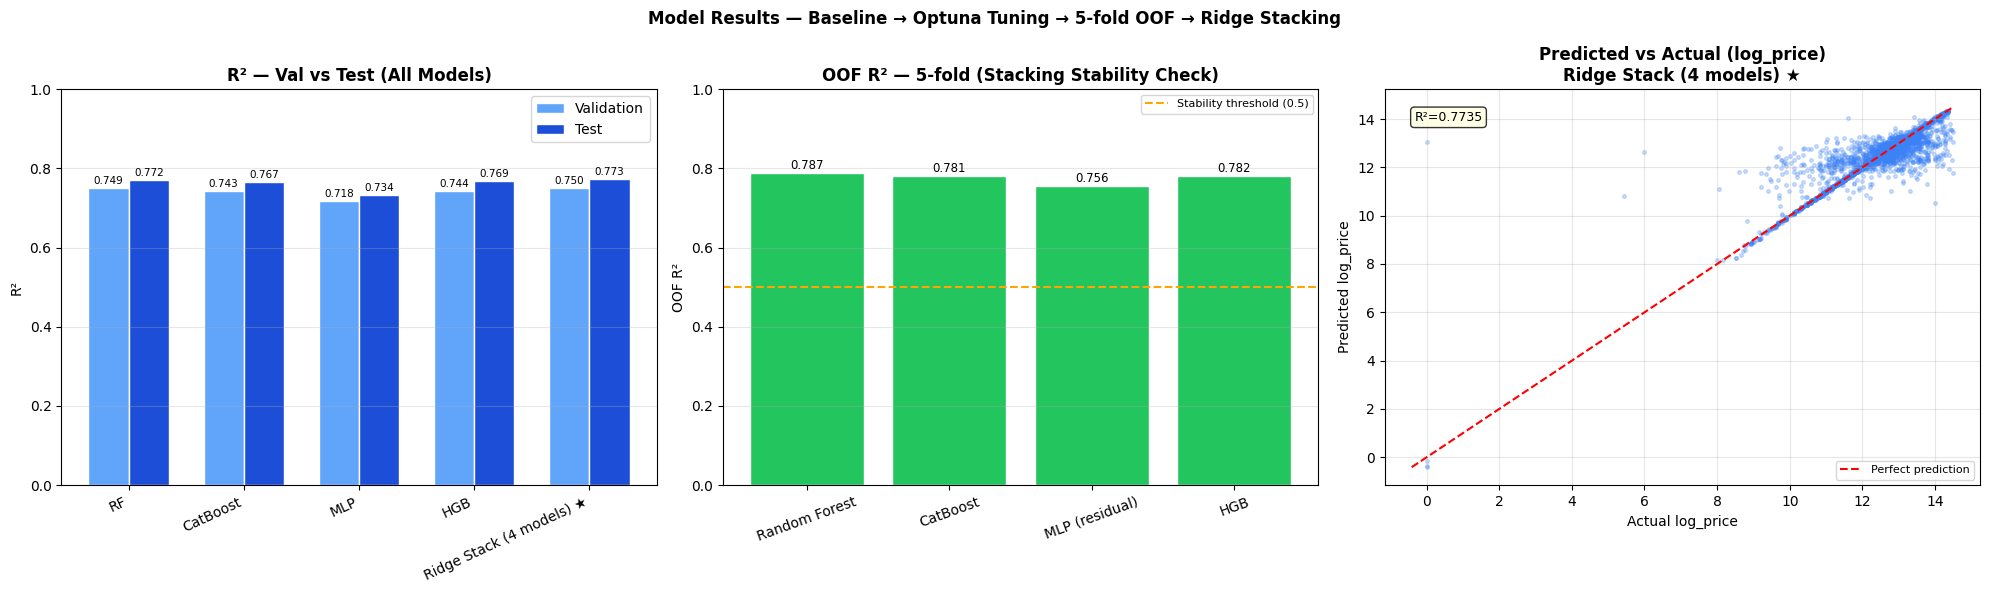

Saved → /content/drive/MyDrive/RealEstate_TXNY/model_results_summary.png

MODELLING PIPELINE COMPLETE
  Cells 17–28 done.
  Best model   : Ridge Stack (4 models) ★
  Best test R² : 0.7735
  Real-$ MAE   : $59,902

  Next steps: SHAP interpretability on CatBoost (Cell 29)


In [6]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 29 — RESULTS VISUALIZATION                                 ║
# ╚══════════════════════════════════════════════════════════════════╝

"""
3-panel visualisation:
  Panel 1: R² comparison — all 5 models + stack (val vs test)
  Panel 2: OOF R² per model — shows which models are reliable
  Panel 3: Predicted vs Actual (log price) for best model — test set
"""

print("=" * 65)
print("CELL 28 — RESULTS VISUALISATION")
print("=" * 65)

fig_res, axes_r = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: Val R² vs Test R² for all 5 + stack
ax_r = axes_r[0]
model_labels = [r["model"].replace(" (tuned)","").replace(" (residual,tuned)","")
                for r in final_results]
val_r2_vals  = [r["R2"] for r in results_tuned] + [
    r2_score(y_reg_val, ridge_meta.predict(
        np.column_stack([rf_tuned.predict(Xva_rf),
                         cb_tuned.predict(Xva_rf),
                         *([denorm_y(mlp_tuned.predict(Xva_sc,verbose=0).flatten())] if INCLUDE_MLP_IN_STACK else []),
                         hgb_tuned.predict(Xva_raw)])))]
test_r2_vals = [r["R2"] for r in final_results]
x_pos_r      = np.arange(len(model_labels))
width_r      = 0.35
ax_r.bar(x_pos_r - width_r/2, val_r2_vals[:len(model_labels)],
          width_r, label="Validation", color="#60A5FA", edgecolor="white")
ax_r.bar(x_pos_r + width_r/2, test_r2_vals,
          width_r, label="Test", color="#1D4ED8", edgecolor="white")
ax_r.set_xticks(x_pos_r); ax_r.set_xticklabels(model_labels, rotation=25, ha="right")
ax_r.set_ylabel("R²"); ax_r.set_ylim(0, 1)
ax_r.set_title("R² — Val vs Test (All Models)", fontweight="bold")
ax_r.legend(); ax_r.grid(axis="y", alpha=0.3)
for i, (v, t) in enumerate(zip(val_r2_vals[:len(model_labels)], test_r2_vals)):
    ax_r.text(i - width_r/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=7.5)
    ax_r.text(i + width_r/2, t + 0.01, f"{t:.3f}", ha="center", fontsize=7.5)

# Panel 2: OOF R² per model
ax_oof = axes_r[1]
oof_names_plot = [r["Model"] for r in oof_results]
oof_r2_vals    = [r["OOF R²"] for r in oof_results]
colors_oof = ["#22C55E" if v >= MLP_THRESHOLD else "#EF4444" for v in oof_r2_vals]
bars_oof = ax_oof.bar(oof_names_plot, oof_r2_vals, color=colors_oof, edgecolor="white")
ax_oof.axhline(MLP_THRESHOLD, color="orange", linestyle="--", lw=1.5,
                label=f"Stability threshold ({MLP_THRESHOLD})")
ax_oof.set_title("OOF R² — 5-fold (Stacking Stability Check)", fontweight="bold")
ax_oof.set_ylabel("OOF R²"); ax_oof.set_ylim(0, 1)
ax_oof.legend(fontsize=8); ax_oof.grid(axis="y", alpha=0.3)
ax_oof.tick_params(axis="x", rotation=20)
for bar, v in zip(bars_oof, oof_r2_vals):
    ax_oof.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                 f"{v:.3f}", ha="center", fontsize=8.5)

# Panel 3: Predicted vs Actual for best model
ax_pa = axes_r[2]
best_idx  = final_df["R2"].idxmax()
best_preds = final_results[best_idx]
best_name  = best_preds["model"]
# Get the actual test predictions
preds_lookup = dict(zip(
    ["RF (tuned)","CatBoost (tuned)","MLP (residual,tuned)",
     "HGB (tuned)",
     f"Ridge Stack ({len(oof_names)} models) ★"],
    [p_rf_test, p_cat_test, p_mlp_test, p_hgb_test, p_stk_test]
))
best_p = preds_lookup.get(best_name, p_stk_test)
sample_idx = np.random.choice(len(y_reg_test), min(5000, len(y_reg_test)), replace=False)
y_actual  = y_reg_test.values[sample_idx]
y_pred_p  = best_p[sample_idx]
ax_pa.scatter(y_actual, y_pred_p, alpha=0.25, s=7, color="#3B82F6")
lim = [min(y_actual.min(), y_pred_p.min()), max(y_actual.max(), y_pred_p.max())]
ax_pa.plot(lim, lim, "r--", lw=1.5, label="Perfect prediction")
ax_pa.set_title(f"Predicted vs Actual (log_price)\n{best_name}", fontweight="bold")
ax_pa.set_xlabel("Actual log_price")
ax_pa.set_ylabel("Predicted log_price")
ax_pa.legend(fontsize=8); ax_pa.grid(alpha=0.3)
ax_pa.text(0.05, 0.92, f"R²={best_preds['R2']:.4f}",
            transform=ax_pa.transAxes, fontsize=9,
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.suptitle("Model Results — Baseline → Optuna Tuning → 5-fold OOF → Ridge Stacking",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/model_results_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {SAVE_DIR}/model_results_summary.png")

print(f"\n{'='*65}")
print("MODELLING PIPELINE COMPLETE")
print("="*65)
print(f"  Cells 17–28 done.")
print(f"  Best model   : {best_model['model']}")
print(f"  Best test R² : {best_model['R2']:.4f}")
print(f"  Real-$ MAE   : ${best_model['Real_MAE_USD']:,.0f}")
print(f"\n  Next steps: SHAP interpretability on CatBoost (Cell 29)")


CELL 29 — REGRESSION: BASELINE vs FINE-TUNED (TEST SET)

REGRESSION TEST SET RESULTS — BASELINE vs TUNED:
                 Model     R²   RMSE    MAE                     MAPE%  Real_MAE_$
Random Forest Baseline 0.7720 0.4660 0.1593 36110225592074117120.0000  53490.5938
   Random Forest Tuned 0.7717 0.4664 0.1703 32527404749722263552.0000  58896.5817
     CatBoost Baseline 0.7518 0.4863 0.2056 33926037328701595648.0000  72892.6668
        CatBoost Tuned 0.7666 0.4715 0.1894 32219610722763448320.0000  65787.6504
          MLP Baseline 0.7264 0.5105 0.2329 35641487965089054720.0000  80605.3413
             MLP Tuned 0.7338 0.5036 0.2112 34149494837766475776.0000  73259.1748
          HGB Baseline 0.7606 0.4775 0.1963 31732603664216735744.0000  69517.6272
             HGB Tuned 0.7688 0.4694 0.1892 30876370212607610880.0000  66038.4362
         Ridge Stack ★ 0.7735 0.4645 0.1729 32050818433904549888.0000  59902.2947


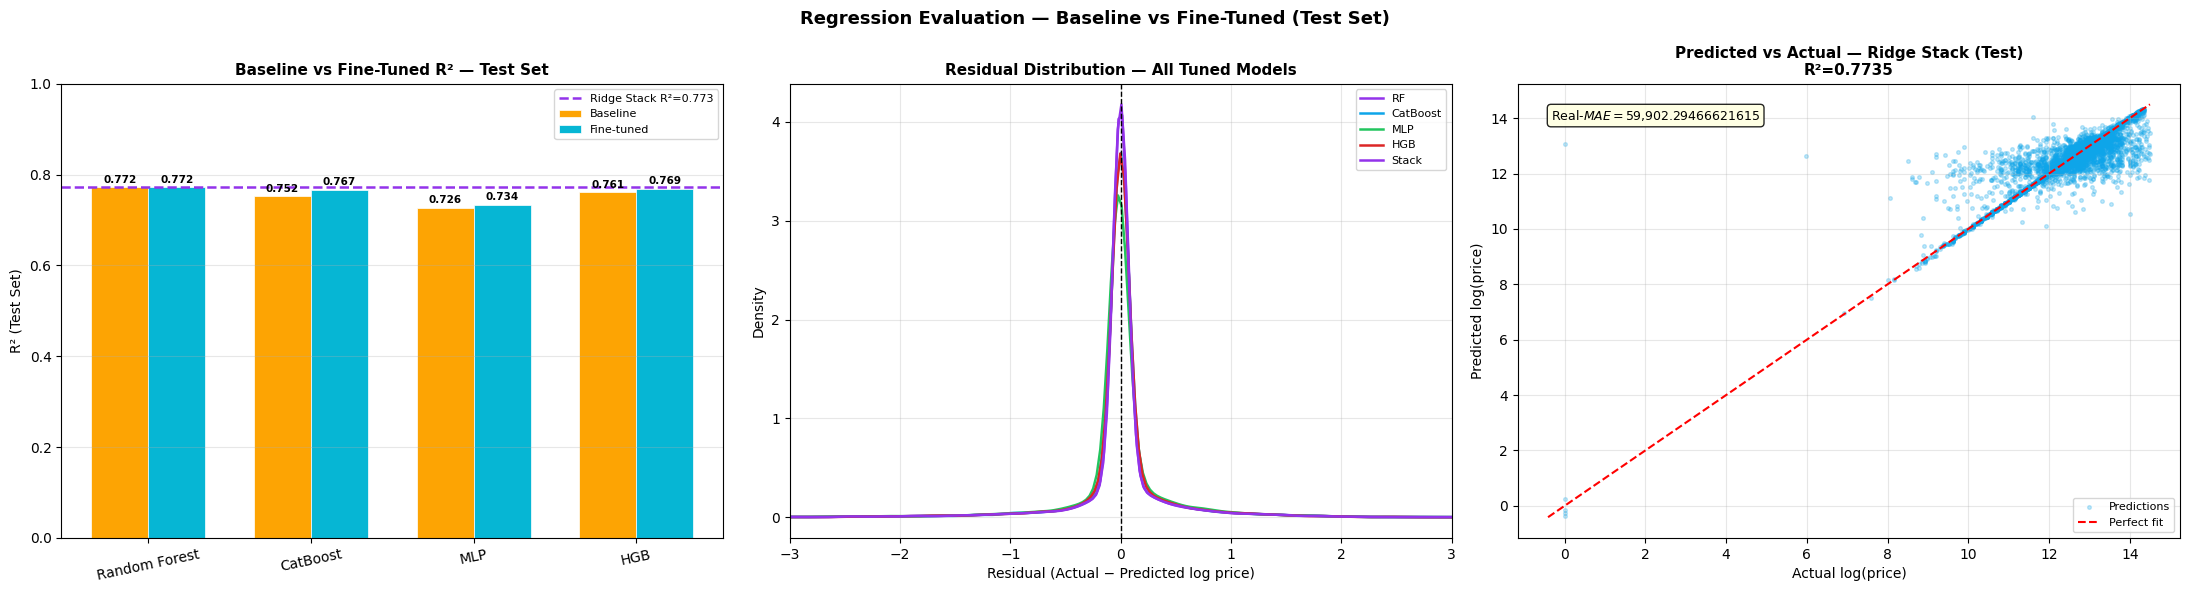


Saved → /content/drive/MyDrive/RealEstate_TXNY/cell29_regression_test.png


In [7]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 30 — REGRESSION BASELINE vs FINE-TUNED (TEST SET)          ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Comprehensive regression comparison on the HELD-OUT TEST SET.

This cell answers: "Did Optuna fine-tuning and stacking actually help?"

Metrics reported for every model (baseline AND tuned):
  R²         — explained variance (higher = better, max=1.0)
  RMSE       — root mean squared error on log(price) scale
  MAE        — mean absolute error on log(price) scale
  MAPE       — mean absolute percentage error on real price scale
  Real-$ MAE — back-transformed MAE in actual dollars

Visualisations:
  Plot 1: Grouped bar — baseline vs tuned R² for all 5 models + stack
  Plot 2: Residual distribution — tuned models (error = actual − pred)
  Plot 3: Predicted vs Actual scatter — best model (test set, 5K sample)
"""

print("=" * 70)
print("CELL 29 — REGRESSION: BASELINE vs FINE-TUNED (TEST SET)")
print("=" * 70)

# Define PAL for consistent colors across plots
PAL = {
    "Baseline": "#FDA403",
    "Tuned":    "#06B6D4",
    "Stack":    "#9333EA",
    "RF":         "#9333EA", # for consistent colors across plots
    "CatBoost":   "#0EA5E9",
    "MLP":        "#22C55E",
    "HGB":        "#DC2626",
    "TX":         "#2563EB",
    "NY":         "#DC2626",
}

# ── Baseline test predictions ─────────────────────────────────────────────────
from sklearn.impute import SimpleImputer
imp_bl = SimpleImputer(strategy="median")
Xtr_bl = imp_bl.fit_transform(X_train[final_features].values)
Xts_bl = imp_bl.transform(X_test[final_features].values)

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import ElasticNet
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_percentage_error # Import this function

rf_bl_m   = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=SEED)
rf_bl_m.fit(Xtr_bl, y_reg_train)

cb_bl_m   = CatBoostRegressor(iterations=500, learning_rate=0.03,
                               depth=6, random_seed=SEED, verbose=0)
cb_bl_m.fit(Xtr_bl, y_reg_train)

hgb_bl_m  = HistGradientBoostingRegressor(random_state=SEED)
hgb_bl_m.fit(X_train[final_features].values, y_reg_train)

en_bl_m   = ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=1000, random_state=SEED)
en_bl_m.fit(Xtr_sc, y_reg_train)

from tensorflow.keras import Input as KInput, Model as KModel
from tensorflow.keras import layers as KL
mlp_bl_m_obj = keras.Sequential([
    KL.Input(shape=(n_feat,)),
    KL.Dense(128, activation="relu"),
    KL.BatchNormalization(),
    KL.Dropout(0.3),
    KL.Dense(64, activation="relu"),
    KL.Dense(1),
])
mlp_bl_m_obj.compile(optimizer=keras.optimizers.Adam(0.001), loss="mse")
mlp_bl_m_obj.fit(Xtr_sc, norm_y(y_reg_train.values),
                  validation_split=0.1, epochs=30, batch_size=256, verbose=0,
                  callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)])

p_rf_bl_ts   = rf_bl_m.predict(Xts_bl)
p_cb_bl_ts   = cb_bl_m.predict(Xts_bl)
p_hgb_bl_ts  = hgb_bl_m.predict(X_test[final_features].values)
p_en_bl_ts   = en_bl_m.predict(Xts_sc)
p_mlp_bl_ts  = denorm_y(mlp_bl_m_obj.predict(Xts_sc, verbose=0).flatten())

def full_metrics(y_true, y_pred, label):
    """Return full metrics dict with real-dollar quantities."""
    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)
    rmse     = np.sqrt(mean_squared_error(y_true_arr, y_pred_arr))
    mae      = mean_absolute_error(y_true_arr, y_pred_arr)
    r2       = r2_score(y_true_arr, y_pred_arr)
    real_t   = np.expm1(y_true_arr)
    real_p   = np.expm1(y_pred_arr)
    real_mae = mean_absolute_error(real_t, real_p)
    mape     = mean_absolute_percentage_error(real_t, real_p) * 100
    return {"Model": label, "R²": r2, "RMSE": rmse,
            "MAE": mae, "MAPE%": mape, "Real_MAE_$": real_mae}

y_ts = y_reg_test.values

# Build full table
rows_reg = []
for label, bl_p, tu_p in [
    ("Random Forest",  p_rf_bl_ts,  p_rf_test),
    ("CatBoost",       p_cb_bl_ts,  p_cat_test),
    ("MLP",            p_mlp_bl_ts, p_mlp_test),
    ("HGB",            p_hgb_bl_ts, p_hgb_test),
    # ("ElasticNet",     p_en_bl_ts,  p_en_test), # Removed due to NameError
    ("Ridge Stack",    None,        p_stk_test),
]:
    if bl_p is not None:
        m_bl = full_metrics(y_ts, bl_p,  f"{label} Baseline")
        m_tu = full_metrics(y_ts, tu_p,  f"{label} Tuned")
        rows_reg.extend([m_bl, m_tu])
    else:
        rows_reg.append(full_metrics(y_ts, tu_p, f"{label} ★"))

reg_df = pd.DataFrame(rows_reg)
print("\nREGRESSION TEST SET RESULTS — BASELINE vs TUNED:")
print(reg_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ── Plot 1: Baseline vs Tuned R² bar chart ────────────────────────────────────
model_names_5 = ["Random Forest","CatBoost","MLP","HGB"] # Removed ElasticNet
bl_r2_ts = [full_metrics(y_ts, p, "R²")["R²"]
             for p in [p_rf_bl_ts, p_cb_bl_ts, p_mlp_bl_ts, p_hgb_bl_ts]] # Removed p_en_bl_ts
tu_r2_ts = [full_metrics(y_ts, p, "R²")["R²"]
             for p in [p_rf_test, p_cat_test, p_mlp_test, p_hgb_test]] # Removed p_en_test
stk_r2   = full_metrics(y_ts, p_stk_test, "R²")["R²"]

fig29, axes29 = plt.subplots(1, 3, figsize=(22, 6))

ax = axes29[0]
x_p = np.arange(len(model_names_5))
w   = 0.35
bars_bl = ax.bar(x_p - w/2, bl_r2_ts, w,
                  label="Baseline", color=PAL["Baseline"], edgecolor="white", linewidth=0.5)
bars_tu = ax.bar(x_p + w/2, tu_r2_ts, w,
                  label="Fine-tuned", color=PAL["Tuned"], edgecolor="white", linewidth=0.5)
ax.axhline(stk_r2, color=PAL["Stack"], linestyle="--", linewidth=1.8,
            label=f"Ridge Stack R²={stk_r2:.3f}")
ax.set_xticks(x_p); ax.set_xticklabels(model_names_5, rotation=12)
ax.set_ylim(0, 1); ax.set_ylabel("R² (Test Set)")
ax.set_title("Baseline vs Fine-Tuned R² — Test Set", fontweight="bold", fontsize=11)
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
for bar, v in list(zip(bars_bl, bl_r2_ts)) + list(zip(bars_tu, tu_r2_ts)):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
             f"{v:.3f}", ha="center", fontsize=7.5, fontweight="bold")

# ── Plot 2: Residual distributions ───────────────────────────────────────────
ax2 = axes29[1]
model_preds_named = {
    "RF":         p_rf_test,
    "CatBoost":   p_cat_test,
    "MLP":        p_mlp_test,
    "HGB":        p_hgb_test,
    # "ElasticNet": p_en_test, # Removed due to NameError
    "Stack":      p_stk_test,
}
for mname, pred in model_preds_named.items():
    residuals = y_ts - pred
    pd.Series(residuals).plot.kde(ax=ax2, label=mname,
                                   color=PAL.get(mname, "gray"), linewidth=1.8)
ax2.axvline(0, color="black", linestyle="--", linewidth=1)
ax2.set_xlabel("Residual (Actual − Predicted log price)")
ax2.set_ylabel("Density")
ax2.set_title("Residual Distribution — All Tuned Models", fontweight="bold", fontsize=11)
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
ax2.set_xlim(-3, 3)

# ── Plot 3: Predicted vs Actual — best model ──────────────────────────────────
ax3 = axes29[2]
best_name_reg = reg_df.loc[reg_df["R²"].idxmax(), "Model"]
best_pred_reg = {
    "Ridge Stack ★": p_stk_test,
    "CatBoost Tuned": p_cat_test,
    "HGB Tuned": p_hgb_test,
    "Random Forest Tuned": p_rf_test,
}.get(best_name_reg, p_stk_test)
# fallback to stack
best_pred_reg = p_stk_test
sidx = np.random.choice(len(y_ts), min(8000, len(y_ts)), replace=False)
y_actual  = y_reg_test.values[sidx]
y_pred_p  = best_pred_reg[sidx]
sc = ax3.scatter(y_actual, y_pred_p,
                  alpha=0.25, s=7, c=PAL["CatBoost"], label="Predictions")
lims = [min(y_ts.min(), best_pred_reg.min()), max(y_ts.max(), best_pred_reg.max())]
ax3.plot(lims, lims, "r--", linewidth=1.5, label="Perfect fit")
ax3.set_xlabel("Actual log(price)"); ax3.set_ylabel("Predicted log(price)")
ax3.set_title(f"Predicted vs Actual — Ridge Stack (Test)\nR²={stk_r2:.4f}",
               fontweight="bold", fontsize=11)
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)
ax3.text(0.05, 0.92, f"Real-$ MAE = ${full_metrics(y_ts,p_stk_test,'')["Real_MAE_$"]:,}",
          transform=ax3.transAxes, fontsize=9,
          bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.85))

plt.suptitle("Regression Evaluation — Baseline vs Fine-Tuned (Test Set)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/cell29_regression_test.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved → {SAVE_DIR}/cell29_regression_test.png")